In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import ( 
                                accuracy_score,
                                precision_score,
                                recall_score,
                                f1_score
)

In [25]:
train_data=fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)

In [26]:
test_data=fetch_20newsgroups( 
    subset="test",
    remove=("headers","footers","quotes")
)

In [27]:
X_train_text=train_data.data
y_train=train_data.target

X_test_text=test_data.data
y_test=test_data.target

class_names= train_data.target_names


In [28]:
print(f"training documents:{len(X_train_text)}")
print(f"testing documents:{len(X_test_text)}")
print(f"class names:{len(class_names)}")

training documents:11314
testing documents:7532
class names:20


In [29]:
vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2
)

X_train=vectorizer.fit_transform(X_train_text)
X_test=vectorizer.transform(X_test_text)

In [30]:
print("Training feATURE MATRIX:",X_train.shape)
print("Training feATURE MATRIX:",X_test.shape)


Training feATURE MATRIX: (11314, 39115)
Training feATURE MATRIX: (7532, 39115)


In [31]:
mnb=MultinomialNB()

mnb.fit( X_train, y_train )

y_pred_mnb=mnb.predict(X_test)

In [32]:
binary_vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary=binary_vectorizer.fit_transform(X_train_text)
X_test_binary=binary_vectorizer.transform(X_test_text)


In [33]:
bnb=BernoulliNB()

bnb.fit(X_train_binary,y_train)

y_pred_bnb=bnb.predict(X_test_binary)

In [41]:
results=pd.DataFrame({
    "Model":[
        "Multinomial NB",
        "Bernoulli NB"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_bnb)
    ],

    "Precision":[
        precision_score(y_test, y_pred_mnb,average="macro"),
        precision_score(y_test, y_pred_bnb,average="macro")
    ],

    "Recall":[
         recall_score(y_test, y_pred_mnb,average="macro"),
         recall_score(y_test, y_pred_bnb,average="macro")
    ],

    "F1_Score":[
        f1_score(y_test, y_pred_mnb,average="macro"),
        f1_score(y_test, y_pred_bnb,average="macro")
    ]
})

results
    

    


        
        
        

,Model,Accuracy,Precision,Recall,F1_Score
0,Multinomial NB,0.651089,0.634470,0.636933,0.617859
1,Bernoulli NB,0.485130,0.616678,0.469434,0.467865


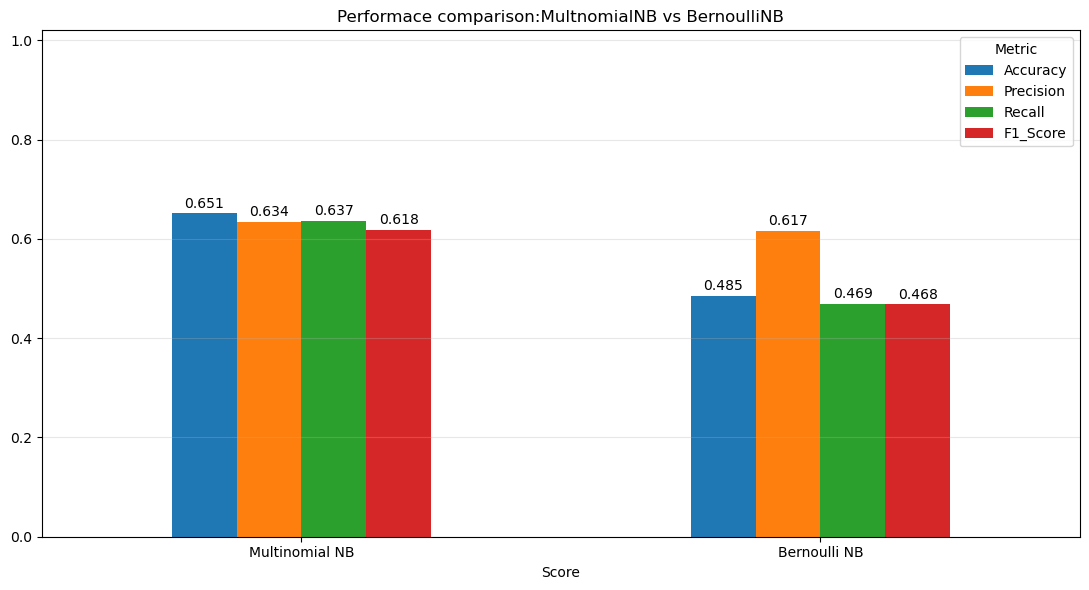

In [42]:
results_metrics=results[
    [ "Model","Accuracy","Precision","Recall","F1_Score"]
    ]

ax=results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Performace comparison:MultnomialNB vs BernoulliNB")

plt.xlabel("Model")
plt.xlabel("Score")

plt.ylim(0,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
    plt.tight_layout()
plt.show()